### Modelagem de eficiência de PSCs: Baseline, Random Forest e SHAP

**Pipeline:** Baseline → Random Forest (com validação cruzada agrupada por artigo) → SHAP (por permutação).

#### Importação de bibliotecas

In [22]:
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import sparse
import shap
import shap.utils

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.max_colwidth', 120)
SEMENTE_ALEATORIA = 42
np.random.seed(SEMENTE_ALEATORIA)

#### Carregando os dados


In [23]:
nome_do_arquivo = 'extracoes_norm.jsonl'

dados = pd.read_csv(nome_do_arquivo, encoding='utf-8-sig')

print(f'Linhas (extrações): {len(dados)}')
print(f'Artigos únicos (coluna "i"): {dados["i"].nunique()}')
dados.head(3)

Linhas (extrações): 2011
Artigos únicos (coluna "i"): 1455


,i,extracao_id,composicao_original,FA,MA,Cs,Rb,K,Na,Pb,...,Br,Cl,F,eficiencia,eficiencia_min,eficiencia_max,unidade,metodo_de_deposicao,arquitetura,evidencia
0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,3.8,NaN,NaN,%,NaN,NaN,the first report on perovskite solar cells with an efficiency of 3.8% in 2009
1,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,19.3,NaN,NaN,%,NaN,planar-heterojunction,perovskite solar cells with a planar-heterojunction structure have achieved an efficiency of 19.3%
2,0,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,16.7,NaN,NaN,%,NaN,mesoporous,perovskite solar cells with conventional mesoporous structure have achieved a certified efficiency above 16.7%


#### Definindo a variável-alvo: eficiência média


In [24]:
dados['eficiencia_media'] = dados['eficiencia']

sem_valor_pontual = dados['eficiencia_media'].isna()
tem_intervalo = dados['eficiencia_min'].notna() | dados['eficiencia_max'].notna()
dados.loc[sem_valor_pontual & tem_intervalo, 'eficiencia_media'] = (
    dados.loc[sem_valor_pontual & tem_intervalo, ['eficiencia_min', 'eficiencia_max']].mean(axis=1)
)

antes = len(dados)
dados = dados.dropna(subset=['eficiencia_media']).reset_index(drop=True)
print(f'Linhas sem nenhum valor de eficiência (removidas): {antes - len(dados)}')

LIMITE_PLAUSIVEL = 40.0  # % — ajuste conforme sua revisão manual
outliers = dados['eficiencia_media'] > LIMITE_PLAUSIVEL
dados = dados.loc[~outliers].reset_index(drop=True)
print(f'Linhas acima de {LIMITE_PLAUSIVEL}% removidas: {outliers.sum()}')
print(f'Linhas finais para modelagem: {len(dados)}')

Linhas sem nenhum valor de eficiência (removidas): 16
Linhas acima de 40.0% removidas: 6
Linhas finais para modelagem: 1989


#### Features: composição, método e arquitetura

In [7]:
SITIOS = ['FA', 'MA', 'Cs', 'Rb', 'K', 'Na', 'Pb', 'Sn', 'Ge', 'I', 'Br', 'Cl', 'F']

X_estrutural = dados[SITIOS].fillna(0.0).values

dados['texto_processo'] = (dados['metodo_de_deposicao'].fillna('') + ' ' + dados['arquitetura'].fillna(''))
sem_info_processo = (dados['texto_processo'].str.strip() == '')
print(f'Linhas sem nenhuma informação de método/arquitetura: {sem_info_processo.sum()} '
      f'({100 * sem_info_processo.mean():.1f}%) — ficam só com a composição como feature')

tfidf = TfidfVectorizer(max_features=200, ngram_range=(1, 2), min_df=3, stop_words='english')
X_processo = tfidf.fit_transform(dados['texto_processo'])

nomes_features = SITIOS + list(tfidf.get_feature_names_out())

X = sparse.hstack([sparse.csr_matrix(X_estrutural), X_processo]).tocsr()
y = dados['eficiencia_media'].values
grupos = dados['i'].values   # cada artigo é um grupo

print(f'\nX: {X.shape}  ({len(SITIOS)} elementos + {X_processo.shape[1]} termos de método/arquitetura)')
print(f'y: faixa {y.min():.1f}% – {y.max():.1f}%')

Linhas sem nenhuma informação de método/arquitetura: 1008 (50.7%) — ficam só com a composição como feature

X: (1989, 213)  (13 elementos + 200 termos de método/arquitetura)
y: faixa 0.0% – 40.0%


#### Validação cruzada agrupada por artigo

In [26]:
N_FOLDS = 5
gkf = GroupKFold(n_splits=N_FOLDS)

def avaliar_com_grupo(modelo, X, y, grupos, cv):
    """Roda validação cruzada agrupada manualmente para poder tirar MAE, RMSE e R² juntos."""
    maes, rmses, r2s = [], [], []
    for treino_idx, teste_idx in cv.split(X, y, groups=grupos):
        modelo.fit(X[treino_idx], y[treino_idx])
        pred = modelo.predict(X[teste_idx])
        maes.append(mean_absolute_error(y[teste_idx], pred))
        rmses.append(mean_squared_error(y[teste_idx], pred) ** 0.5)
        r2s.append(r2_score(y[teste_idx], pred))
    return np.array(maes), np.array(rmses), np.array(r2s)

#### Baseline


In [25]:
baseline = DummyRegressor(strategy='mean')
mae_bsl, rmse_bsl, r2_bsl = avaliar_com_grupo(baseline, X, y, grupos, gkf)

print(f'Baseline — {N_FOLDS}-fold agrupado por artigo:')
print(f'  MAE : {mae_bsl.mean():.2f} ± {mae_bsl.std():.2f} pp')
print(f'  RMSE: {rmse_bsl.mean():.2f} ± {rmse_bsl.std():.2f}')
print(f'  R²  : {r2_bsl.mean():.3f} ± {r2_bsl.std():.3f}')

Baseline — 5-fold agrupado por artigo:
  MAE : 6.12 ± 0.19 pp
  RMSE: 7.64 ± 0.17
  R²  : -0.000 ± 0.000


#### Random Forest

In [10]:
rf = RandomForestRegressor(
    n_estimators=300,
    min_samples_leaf=2,
    random_state=SEMENTE_ALEATORIA,
    n_jobs=-1,
)

mae_rf, rmse_rf, r2_rf = avaliar_com_grupo(rf, X, y, grupos, gkf)

print(f'Random Forest — {N_FOLDS}-fold agrupado por artigo:')
print(f'  MAE : {mae_rf.mean():.2f} ± {mae_rf.std():.2f} pp')
print(f'  RMSE: {rmse_rf.mean():.2f} ± {rmse_rf.std():.2f}')
print(f'  R²  : {r2_rf.mean():.3f} ± {r2_rf.std():.3f}')

Random Forest — 5-fold agrupado por artigo:
  MAE : 4.86 ± 0.10 pp
  RMSE: 6.39 ± 0.22
  R²  : 0.297 ± 0.058


#### Comparação dos modelos

In [27]:
comparacao = pd.DataFrame({
    'MAE (pp)': [mae_bsl.mean(), mae_rf.mean()],
    'RMSE (pp)': [rmse_bsl.mean(), rmse_rf.mean()],
    'R²': [r2_bsl.mean(), r2_rf.mean()],
}, index=['Baseline', 'Random Forest'])

comparacao.round(3)

,MAE (pp),RMSE (pp),R²
Baseline,6.119,7.635,-0.000
Random Forest,4.863,6.391,0.297


#### SHAP


In [28]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEMENTE_ALEATORIA)
treino_idx, teste_idx = next(gss.split(X, y, groups=grupos))

rf_shap = RandomForestRegressor(n_estimators=300, min_samples_leaf=2,
                                 random_state=SEMENTE_ALEATORIA, n_jobs=-1)
rf_shap.fit(X[treino_idx], y[treino_idx])

pred_teste = rf_shap.predict(X[teste_idx])
print(f'Nesta divisão específica — MAE: {mean_absolute_error(y[teste_idx], pred_teste):.2f}  '
      f'R²: {r2_score(y[teste_idx], pred_teste):.3f}')

TAMANHO_AMOSTRA_SHAP = 150

rng = np.random.default_rng(SEMENTE_ALEATORIA)
indices_amostra = rng.choice(X[teste_idx].shape[0],
                              size=min(TAMANHO_AMOSTRA_SHAP, X[teste_idx].shape[0]),
                              replace=False)

X_teste_transformado = X[teste_idx][indices_amostra].toarray()

explainer = shap.Explainer(rf_shap.predict, X_teste_transformado, algorithm='permutation')
shap_values = explainer(X_teste_transformado)

Background dataset has 150 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=150 when initializing the masker.


Nesta divisão específica — MAE: 4.78  R²: 0.338


PermutationExplainer explainer: 151it [00:33,  3.24it/s]                         


##### SHAP separado por grupo de feature

In [30]:
CATIONS_A = ['FA', 'MA', 'Cs', 'Rb', 'K', 'Na']
CATIONS_B = ['Pb', 'Sn', 'Ge']
HALETOS_X = ['I', 'Br', 'Cl', 'F']

indices_A = [nomes_features.index(n) for n in CATIONS_A]
indices_B = [nomes_features.index(n) for n in CATIONS_B]
indices_X = [nomes_features.index(n) for n in HALETOS_X]
indices_processo = [i for i in range(len(nomes_features)) if nomes_features[i] not in SITIOS]

print(f'Sítio A: {len(indices_A)} features | Sítio B: {len(indices_B)} | '
      f'Sítio X: {len(indices_X)} | Arquitetura/método: {len(indices_processo)}')

Sítio A: 6 features | Sítio B: 3 | Sítio X: 4 | Arquitetura/método: 200


##### Sítio A — cátions monovalentes

C:\Users\lilia25019\AppData\Local\Temp\ipykernel_9572\620033063.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


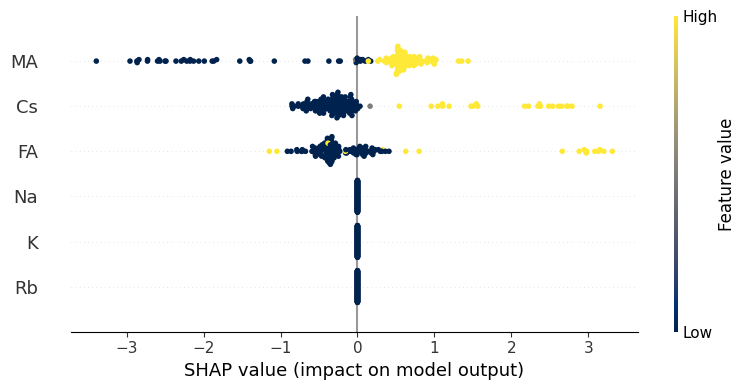

In [29]:
shap.summary_plot(
    shap_values[:, indices_A].values,
    X_teste_transformado[:, indices_A],
    feature_names=[nomes_features[i] for i in indices_A],
    cmap="cividis",
    show=False,
)
plt.gcf().set_size_inches(8, 4)
plt.tight_layout()
plt.show()

##### Sítio B — cátions metálicos bivalentes

C:\Users\lilia25019\AppData\Local\Temp\ipykernel_9572\3591334471.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


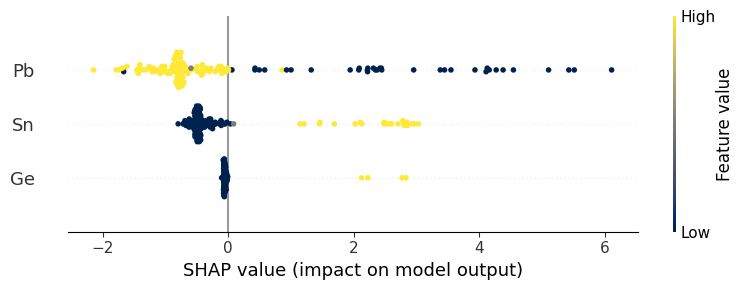

In [31]:
shap.summary_plot(
    shap_values[:, indices_B].values,
    X_teste_transformado[:, indices_B],
    feature_names=[nomes_features[i] for i in indices_B],
    cmap="cividis",
    show=False,
)
plt.gcf().set_size_inches(8, 3)
plt.tight_layout()
plt.show()

##### Sítio X — haletos

C:\Users\lilia25019\AppData\Local\Temp\ipykernel_9572\1239491713.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


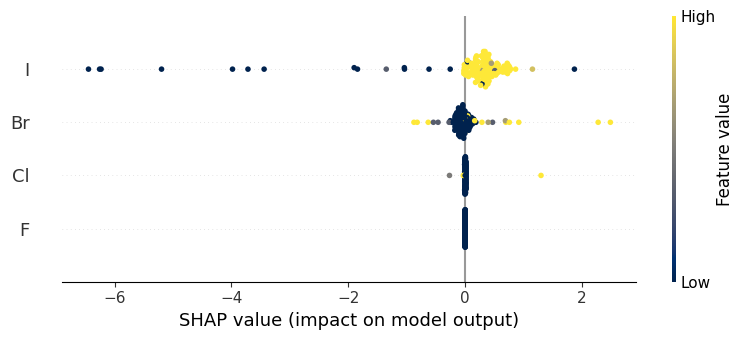

In [32]:
shap.summary_plot(
    shap_values[:, indices_X].values,
    X_teste_transformado[:, indices_X],
    feature_names=[nomes_features[i] for i in indices_X],
    cmap="cividis",
    show=False,
)
plt.gcf().set_size_inches(8, 3.5)
plt.tight_layout()
plt.show()

##### Arquitetura e Método de Deposição

C:\Users\lilia25019\AppData\Local\Temp\ipykernel_9572\158195351.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


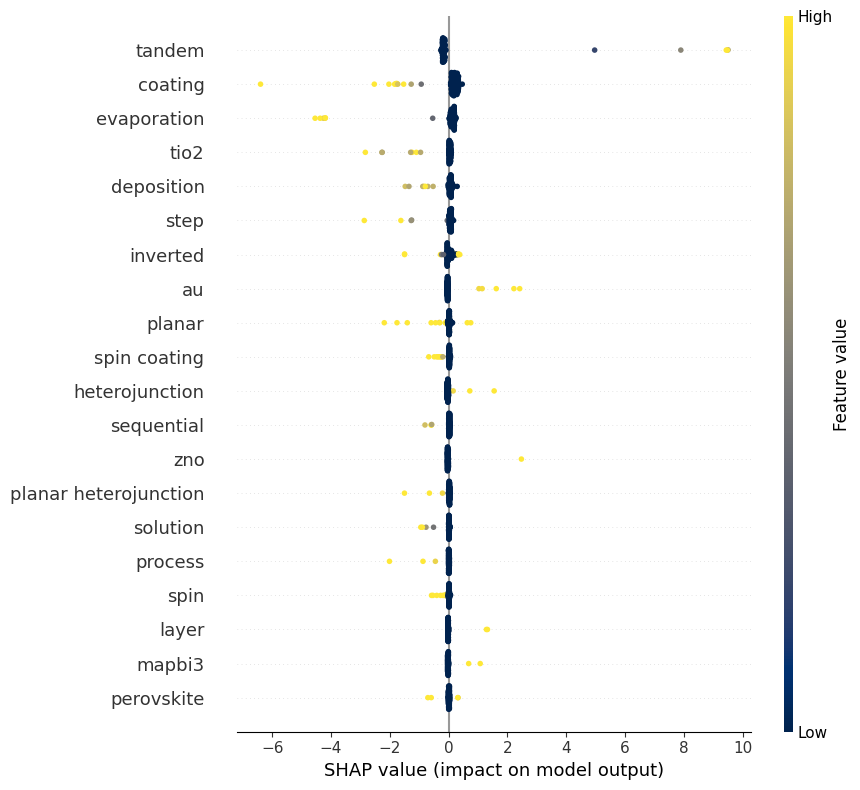

In [33]:
shap.summary_plot(
    shap_values[:, indices_processo].values,
    X_teste_transformado[:, indices_processo],
    feature_names=[nomes_features[i] for i in indices_processo],
    max_display=20,
    cmap="cividis",
    show=False,
)
plt.gcf().set_size_inches(9, 8)
plt.tight_layout()
plt.show()